# Table of contents

* **Introduction**
* **Objective**
* **Gated Recurrent Unit (GRU) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
    * Model Architecture and Model Building (PyTorch)
    * Model Training
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This tutorial outlines the construction of a Gated Recurrent Unit (GRU)-based model for multivariate time series forecasting, implemented using the PyTorch framework. The specific application focuses on predicting the next day’s stock price features, including open, close, low, high, and volume, utilizing historical daily data for the stock EQIX from the NYSE dataset. The methodology encompasses the entire machine learning pipeline, from raw data acquisition and rigorous preprocessing to model design, temporal sequence training, and comprehensive performance evaluation. This project establishes a foundation for developing robust and reproducible deep learning solutions for financial time series analysis.

# Objective

The primary objective involves developing a sequence-to-vector GRU model engineered to capture long-range temporal dependencies within daily financial data. The model must accurately predict the next time step’s vector of financial metrics. Key aims include:

- Transforming raw, heterogeneous data into normalized, sequential inputs suitable for deep learning architectures.
- Designing and training a high-performance GRU architecture incorporating regularization techniques such as dropout and layer normalization to enhance stability and generalization.
- Implementing the early stopping mechanism to efficiently manage the bias-variance trade-off and prevent model overfitting to the training data.
- Quantifying predictive success through standard regression metrics and the crucial metric of directional accuracy, which assesses the practical relevance of the forecasts.

# Gated Recurrent Unit (GRU) Foundations

The Gated Recurrent Unit (GRU) is a sophisticated form of Recurrent Neural Network (RNN) designed specifically to address the fundamental problems of training standard RNNs on long sequences. The GRU, introduced by Cho et al. in 2014, shares a structure and objective similar to the Long Short-Term Memory (LSTM) network but uses fewer parameters and is computationally less complex.

**The Vanishing Gradient Problem**

Standard RNNs suffer from the vanishing gradient problem when processing long sequences. During Backpropagation Through Time (BPTT), gradients (error signals) are multiplied across numerous time steps. If these gradients are small, the repeated multiplication causes the signal to shrink exponentially, becoming effectively zero before reaching the early layers of the network. Consequently, the network fails to learn long-term dependencies, meaning it struggles to relate information at the start of a sequence to events much later.

**GRU Architecture: Gating Mechanisms**

The GRU overcomes the vanishing gradient problem by incorporating gating mechanisms that regulate the flow of information and control what content is stored in, or discarded from, the hidden state. Unlike the LSTM, which uses three gates (input, forget, and output), the GRU uses only two: the Update Gate and the Reset Gate .

**1. The Reset Gate ($\mathbf{r}_t$)**

The reset gate determines how much of the previous hidden state ($\mathbf{h}_{t-1}$) is relevant to the computation of the current time step's candidate hidden state ($\mathbf{\tilde{h}}_t$).

- Function: It is a vector of values between $\mathbf{0}$ and $\mathbf{1}$, typically calculated using the current input ($\mathbf{x}_t$) and the previous hidden state ($\mathbf{h}_{t-1}$), passed through a sigmoid activation function ($\sigma$).
- Concept: A value close to $\mathbf{0}$ means the previous hidden state should be "forgotten," effectively making the current candidate hidden state dependent only on the current input. This mechanism allows the GRU to clear irrelevant information that has been stored long ago, enhancing its ability to adapt quickly to new patterns.

**2. The Update Gate ($\mathbf{z}_t$)**

The update gate controls the degree to which the new candidate hidden state ($\mathbf{\tilde{h}}_t$) should overwrite the previous hidden state ($\mathbf{h}_{t-1}$). It acts as a combined forget and input gate from the LSTM structure.
- Function: Like the reset gate, it is a vector of values between $\mathbf{0}$ and $\mathbf{1}$, also using a sigmoid activation.

**Concept:**

- A value close to $\mathbf{1}$ indicates that the previous hidden state is highly relevant and should be retained in the new hidden state. The network "remembers" the old state.
- A value close to $\mathbf{0}$ indicates that the previous hidden state should be forgotten and largely replaced by the new candidate hidden state. The network "forgets" the old state and "updates" with the new information.

**3. The Hidden State $\mathbf{h}_t$**

The hidden state ($\mathbf{h}_t$) is the core memory unit of the GRU. It is a linear combination of the previous hidden state ($\mathbf{h}_{t-1}$) and the new candidate hidden state ($\mathbf{\tilde{h}}_t$), weighted by the update gate ($\mathbf{z}_t$).
- Candidate Hidden State ($\mathbf{\tilde{h}}_t$): This state represents the potential new memory content based on the current input and a reset version of the previous hidden state. The reset gate's output is multiplied element-wise with $\mathbf{h}_{t-1}$ before passing it through a $\mathbf{tanh}$ activation function.
- Final Hidden State: The final hidden state is determined by the update gate:


$$\mathbf{h}_t = (\mathbf{1} - \mathbf{z}_t) \odot \mathbf{h}_{t-1} + \mathbf{z}_t \odot \mathbf{\tilde{h}}_t$$


The update gate ($\mathbf{z}_t$) regulates the balance: a high $\mathbf{z}_t$ includes more of the new content ($\mathbf{\tilde{h}}_t$), while a low $\mathbf{z}_t$ retains more of the past memory ($\mathbf{h}_{t-1}$).

**Advantages of the GRU**

- Efficiency: The GRU has only two gates and lacks the separate cell state found in the LSTM. This streamlined structure reduces the number of parameters, resulting in faster training times and requiring less computational overhead.
- Long-Term Dependency Learning: The gating mechanism, particularly the update gate, allows the network to bypass short-term time steps and carry relevant information forward across hundreds of time steps, thus effectively solving the vanishing gradient problem.
- Performance: Despite its simpler architecture, the GRU often achieves performance comparable to the more complex LSTM in many sequence modeling tasks, including time series forecasting, natural language processing, and speech recognition.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Field Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">date</td>
    <td class="tg-7zrl">The date range for each data entry. This appears to be a combined string of start and end dates.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">DateTimeCount</td>
    <td class="tg-7zrl">The count of DateTime entries within the specified date range.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">symbol</td>
    <td class="tg-7zrl">An identifier or code, possibly for a financial instrument or category.</td>
    <td class="tg-7zrl">Text</td>
  </tr>
  <tr>
    <td class="tg-7zrl">open</td>
    <td class="tg-7zrl">The opening price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">close</td>
    <td class="tg-7zrl">The closing price/value for a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">low</td>
    <td class="tg-7zrl">The lowest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">high</td>
    <td class="tg-7zrl">The highest price/value recorded within a given period.</td>
    <td class="tg-7zrl">Numeric (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">volume</td>
    <td class="tg-7zrl">The trading volume (number of units traded) within a given period.</td>
    <td class="tg-7zrl">Numeric (Integer)</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/dgawlik/nyse)**

# Pipeline Overview

The project follows a linear, eleven-stage pipeline designed for chronological integrity and modularity:

- Data Loading & Filtering: The NYSE dataset is loaded, filtered specifically for the target stock symbol (EQIX), and strictly sorted chronologically to maintain temporal order.
- Chronological Data Split: The data is divided into training ($\mathbf{80\%}$) and testing ($\mathbf{20\%}$) sets based strictly on time sequence.
- Exploratory Analysis: Initial data understanding is achieved through visualization of price and volume trends and computation of inter-feature correlation matrices.
- Feature Engineering: Date-related features such as year and month are extracted to provide the model with cyclical temporal context; non-predictive columns are discarded.
- Normalization: The $\mathbf{MinMaxScaler}$ is fitted exclusively on the training data's numerical features, and this transformation is subsequently applied to both the training and test sets to maintain data integrity and scale all features within a consistent range.
- Sequence Generation: The sliding window technique is used to create input sequences of length $\mathbf{30}$. The primary training sequences are further partitioned into training ($\mathbf{80\%}$) and validation ($\mathbf{20\%}$) sets.
- Dataset & DataLoader Setup: Sequences are converted to PyTorch $\mathbf{FloatTensor}$ objects and encapsulated within $\mathbf{DataLoader}$ instances for efficient, batch-wise GPU training.
- Model Definition: A custom GRU network is implemented, incorporating layer normalization, dropout, and a linear output head.
- Training Loop: The model is optimized using $\mathbf{Adam}$ with Mean Squared Error (MSE) loss, guided by the early stopping procedure.
- Evaluation: Performance is assessed on the test set using MSE and a metric quantifying the accuracy of predicting the sign of the daily return.
- Visualization: Training loss history and the predicted versus actual sequences are plotted for visual verification of model performance.

# Approach

**Preprocess Pipeline Approach**

The preprocessing phase is meticulously structured to ensure there is no data leakage and that the output is formatted correctly for Recurrent Neural Networks (RNNs).

The sequential steps are as follows:

- Chronological Sorting: The raw data is sorted by the `'date'` column, which is essential for preserving the time-series relationship.
- Stock Filtering: The dataset is reduced to include only records corresponding to the `'EQIX'` symbol.
- Train/Test Partition: A strict $\mathbf{80:20}$ chronological split is performed. This non-randomized partitioning simulates real-world forecasting where future data is entirely unknown.
- Feature Construction: The `'date'` column is parsed to extract `'year'` and `'month'` features, providing the model with non-linear, high-level temporal information. Non-essential identifier columns (e.g., $\mathbf{'symbol'}$) are removed.
- Normalization Theory: Feature scaling is critical for deep learning convergence. The MinMaxScaler is used to transform features to a `[0, 1]` range. The scaler's parameters are `fitted only on the training subset` to prevent test data statistics from influencing the training process.
- Sequence Generation Theory: The RNN inherently processes sequences. A sliding window (`sequence length} = 30`) creates pairs of `(X, y)` where `X` is $\mathbf{30}$ consecutive days of features, and `y` is the features of the $\mathbf{31^{st}}$ day. The resulting sequences from the training data are further split for validation set creation.
- PyTorch Conversion: All generated sequences are cast to `torch.FloatTensor` objects, which is the native data type required by PyTorch models for computation.

**Model Training Approach**

A custom `TimeSeriesRNN` model is constructed to integrate key deep learning concepts for recurrent network stability and performance.

Model Architecture Concepts:

- GRU (Gated Recurrent Unit): GRU layers, a type of recurrent neural network, are employed. They utilize reset and update gates to selectively process and remember information across long sequences, effectively mitigating the vanishing gradient problem inherent in standard RNNs. Two stacked GRU layers are used with a hidden size of $\mathbf{128}$.
- Layer Normalization: Applied to the input of the GRU layers. Unlike batch normalization, layer normalization computes statistics across the features within a single time step and batch element, making it highly effective for sequence data by ensuring stable hidden state dynamics.
- Dropout: A $\mathbf{0.2}$ dropout rate is applied to the output of the GRU layers. This technique randomly sets a fraction of neurons to zero during training, preventing complex co-adaptation of neurons and serving as a powerful `regularization` method against overfitting.
- Linear Output Head: The final hidden state is passed through a `Linear` layer to map the $128$-dimensional latent representation back to the $7$ output features for the next day's prediction.

**Training Configuration:**

- Loss Function: `MSELoss` (Mean Squared Error) is used as the objective function. For regression tasks, `MSE` penalizes large errors more heavily, driving the model to produce predictions close to the actual scaled values.
- Optimization: The `Adam` optimizer is used with a learning rate of $\mathbf{0.01}$. Adam combines the benefits of adaptive learning rates for each parameter with momentum, promoting fast and efficient convergence.
- Early Stopping: Training continues for up to $\mathbf{1000}$ epochs. The crucial Early Stopping mechanism monitors the validation loss. If no improvement in validation loss is observed over $\mathbf{10}$ consecutive epochs (the patience window), training is terminated. This strategy ensures the final model weights are those that performed optimally on unseen validation data, thereby maximizing generalization.

Data Loaders: The training `DataLoader` shuffles the batches to introduce randomness and prevent batch-order dependencies. The validation and test `DataLoader` remain `ordered` to preserve the temporal sequence necessary for correct time-series evaluation and plotting.

**Model Evaluation Approach**

Evaluation focuses on dual criteria: the accuracy of the value prediction and the accuracy of the directional movement prediction, which is more relevant for decision-making.

**Quantitative Metrics:**

- Mean Squared Error (MSE): The primary metric for regression performance, calculated as the average loss on the held-out test set. The reported MSE is in the normalized space.
- Directional Accuracy: This metric transcends simple value error. It calculates the percentage of times the model correctly predicts the sign of the daily return (`close_t+1 - open_t+1`). This is a measure of the model's practical utility in forecasting whether the stock price will go up or down, which is often more critical than the exact price level.

**Visualization:**

- Predictions are generated using the ordered test `DataLoader` to maintain temporal integrity.
- The visualization plots the full time series, clearly segmenting the `train, validation`, and `test` periods.
- A zoomed-in plot focusing solely on the test predictions vs. actuals provides a detailed view of the forecast quality in the future period.

# Setup Environments

**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import math
import sklearn
import sklearn.preprocessing
import datetime
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore", category=FutureWarning, module='seaborn._oldcore')

2026-03-24 16:48:14.481283: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774370894.738745      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774370894.822341      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Data Loading

The process begins with loading the New York Stock Exchange (NYSE) data, which contains various features for multiple stocks over time. The primary challenge in time series analysis is maintaining the chronological integrity of the data to accurately simulate real-world forecasting.

In [2]:
df = pd.read_csv('/kaggle/input/nyse/prices-split-adjusted.csv')
df.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


**Train and Test Dataset Split**

The dataset is initially loaded, and its sheer size necessitates an efficient chronological split into training (80%) and testing (20%) subsets. The data must be sorted strictly by the $\mathbf{date}$ column before splitting. This non-randomized partitioning ensures the training process uses only historical information, and the test set represents the genuinely unseen future data. Violating this constraint would lead to data leakage, resulting in an overly optimistic and unreliable model evaluation. The shapes of the resulting subsets confirm the non-random, time-based division.

In [3]:
df = df.sort_values(by='date', ascending=True).reset_index(drop=True)

test_size_ratio = 0.2 
split_point = int(len(df) * (1 - test_size_ratio))

train = df.iloc[:split_point].copy()
test = df.iloc[split_point:].copy()

print("\nData split chronologically by 'date' column:")
print(f"Train DataFrame shape: {train.shape}")
print(f"Test DataFrame shape: {test.shape}")


Data split chronologically by 'date' column:
Train DataFrame shape: (681011, 7)
Test DataFrame shape: (170253, 7)


In [4]:
train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)

**Stock Selection and Filtering**

For concentrated, single-series modeling, the data is filtered to isolate only the records corresponding to the target stock, $\mathbf{EQIX}$. Focusing on a single ticker simplifies the initial multivariate modeling problem, ensuring that the recurrent model learns the specific temporal patterns and volatility characteristics unique to that equity.

In [5]:
train = train[train.symbol == 'EQIX'].copy()
test = test[test.symbol == 'EQIX'].copy()

train = train.sort_values(by='date').reset_index(drop=True)
test = test.sort_values(by='date').reset_index(drop=True)
train

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0
...,...,...,...,...,...,...,...
1417,2015-08-20,EQIX,284.220001,279.959991,279.920013,284.649994,568700.0
1418,2015-08-21,EQIX,277.160004,271.309998,271.309998,279.790009,1271900.0
1419,2015-08-24,EQIX,260.000000,255.529999,251.000000,267.089996,1306700.0
1420,2015-08-25,EQIX,260.309998,251.110001,250.860001,263.670013,1294200.0


# Exploratory Data Analysis (EDA)

Exploratory analysis provides critical insights into data trends, volatility, and the internal relationships between features, informing the subsequent feature engineering and model design phases.

**Basic Information**

In [6]:
train.head()

,date,symbol,open,close,low,high,volume
0,2010-01-04,EQIX,106.519997,109.559998,106.510002,109.620003,576300.0
1,2010-01-05,EQIX,109.589996,108.540001,108.379997,109.589996,681900.0
2,2010-01-06,EQIX,108.949997,109.529999,108.220001,110.570000,1397500.0
3,2010-01-07,EQIX,109.250000,107.290001,106.639999,110.349998,797200.0
4,2010-01-08,EQIX,106.800003,106.769997,105.900002,107.279999,432400.0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1422 entries, 0 to 1421
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1422 non-null   object 
 1   symbol  1422 non-null   object 
 2   open    1422 non-null   float64
 3   close   1422 non-null   float64
 4   low     1422 non-null   float64
 5   high    1422 non-null   float64
 6   volume  1422 non-null   float64
dtypes: float64(5), object(2)
memory usage: 77.9+ KB


In [8]:
train.describe()

,open,close,low,high,volume
count,1422.000000,1422.000000,1422.000000,1422.000000,1.422000e+03
mean,160.671779,160.734803,158.748868,162.544423,9.128723e+05
std,57.769144,57.761722,57.255626,58.169847,1.064773e+06
min,71.750000,70.339996,69.419998,74.510002,1.524000e+05
25%,98.382502,98.502500,97.042500,99.649997,5.338000e+05
50%,173.614998,173.385002,170.770004,176.120003,7.309500e+05
75%,210.034996,210.097504,208.022495,212.072502,1.040200e+06
max,286.130005,287.420013,283.980011,288.500000,3.057420e+07


**Feature Trends and Stationarity**

The price features ($\mathbf{open, close, low, high}$) display a strong upward, non-stationary trend over the observation period, reflecting significant capital appreciation. The lines remain tightly grouped, indicating low intraday volatility in most periods. The $\mathbf{volume}$ feature, however, is characterized by large, intermittent spikes, suggesting irregular trading activity driven by news or corporate events. Time series models must account for these non-stationary trends and volatility bursts.

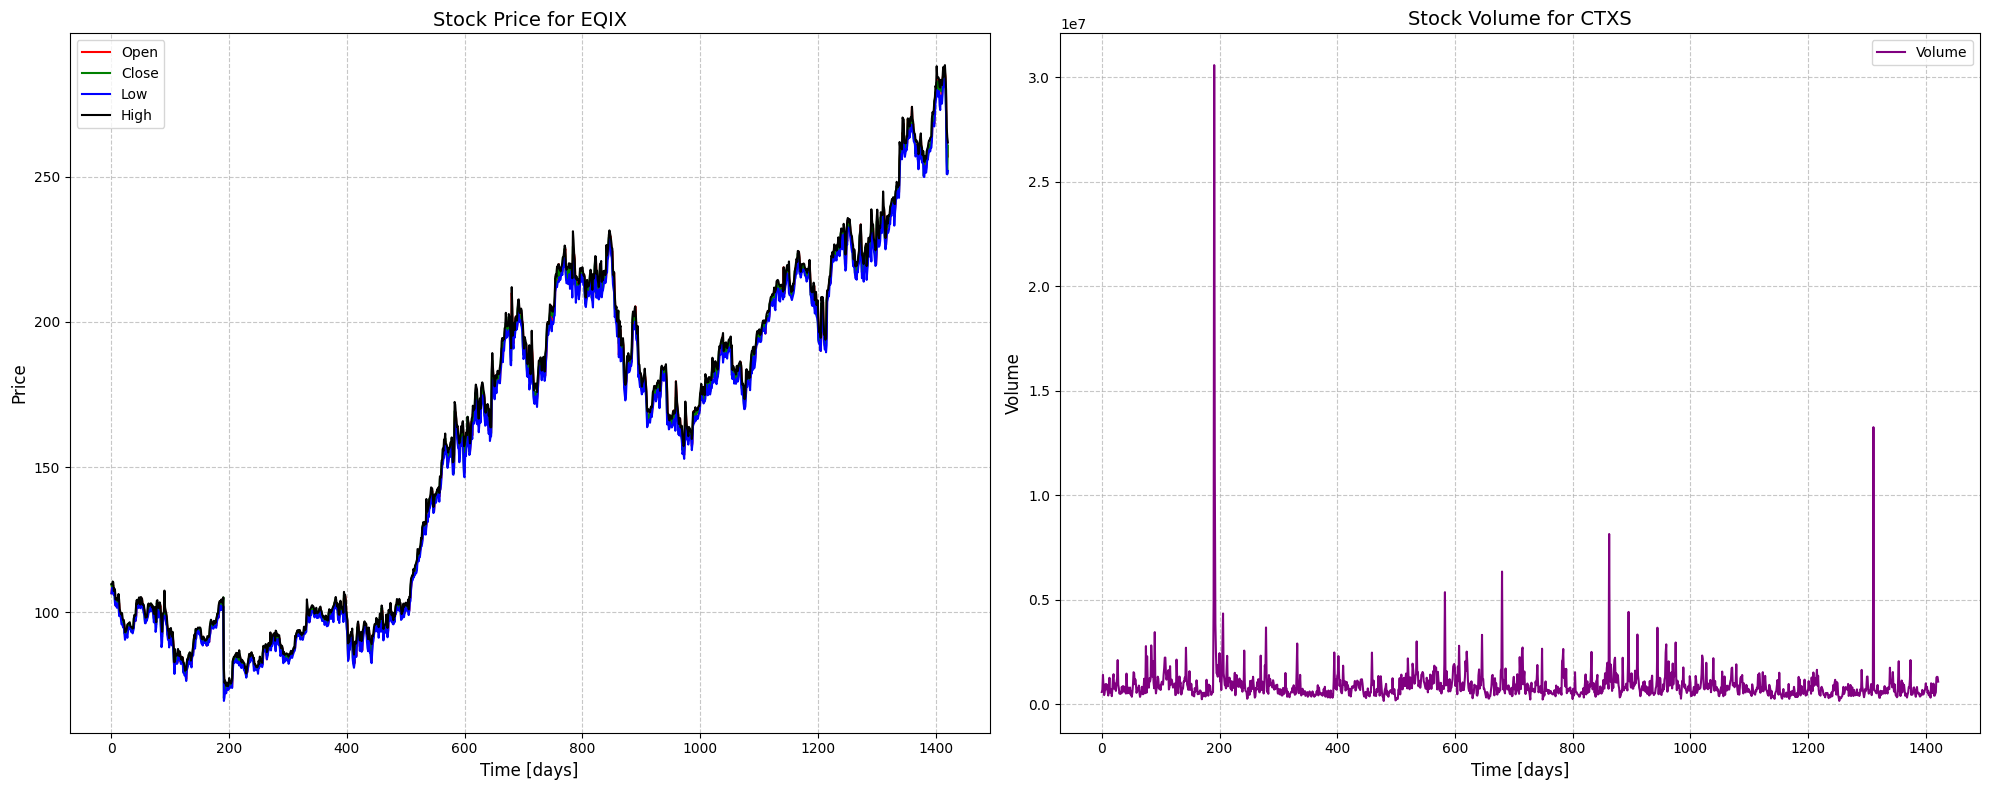

In [9]:
train['time_idx'] = range(len(train))

ctxs_data = train[train.symbol == 'EQIX']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.lineplot(x='time_idx', y='open', data=ctxs_data, color='red', label='Open', ax=axes[0])
sns.lineplot(x='time_idx', y='close', data=ctxs_data, color='green', label='Close', ax=axes[0])
sns.lineplot(x='time_idx', y='low', data=ctxs_data, color='blue', label='Low', ax=axes[0])
sns.lineplot(x='time_idx', y='high', data=ctxs_data, color='black', label='High', ax=axes[0])

axes[0].set_title('Stock Price for EQIX', fontsize=14)
axes[0].set_xlabel('Time [days]', fontsize=12)
axes[0].set_ylabel('Price', fontsize=12)
axes[0].legend(loc='best')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.lineplot(x='time_idx', y='volume', data=ctxs_data, color='purple', label='Volume', ax=axes[1])

axes[1].set_title('Stock Volume for CTXS', fontsize=14)
axes[1].set_xlabel('Time [days]', fontsize=12)
axes[1].set_ylabel('Volume', fontsize=12)
axes[1].legend(loc='best')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Correlation Analysis**

Feature correlation analysis, presented in the heatmap, reveals critical statistical relationships within the time series data.

In [10]:
train = train.drop(columns=['symbol'])
test = test.drop(columns=['symbol'])
train

,date,open,close,low,high,volume,time_idx
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4
...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420


In [11]:
train['date'] = pd.to_datetime(train['date'])

train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train

,date,open,close,low,high,volume,time_idx,year,month,day
0,2010-01-04,106.519997,109.559998,106.510002,109.620003,576300.0,0,2010,1,4
1,2010-01-05,109.589996,108.540001,108.379997,109.589996,681900.0,1,2010,1,5
2,2010-01-06,108.949997,109.529999,108.220001,110.570000,1397500.0,2,2010,1,6
3,2010-01-07,109.250000,107.290001,106.639999,110.349998,797200.0,3,2010,1,7
4,2010-01-08,106.800003,106.769997,105.900002,107.279999,432400.0,4,2010,1,8
...,...,...,...,...,...,...,...,...,...,...
1417,2015-08-20,284.220001,279.959991,279.920013,284.649994,568700.0,1417,2015,8,20
1418,2015-08-21,277.160004,271.309998,271.309998,279.790009,1271900.0,1418,2015,8,21
1419,2015-08-24,260.000000,255.529999,251.000000,267.089996,1306700.0,1419,2015,8,24
1420,2015-08-25,260.309998,251.110001,250.860001,263.670013,1294200.0,1420,2015,8,25


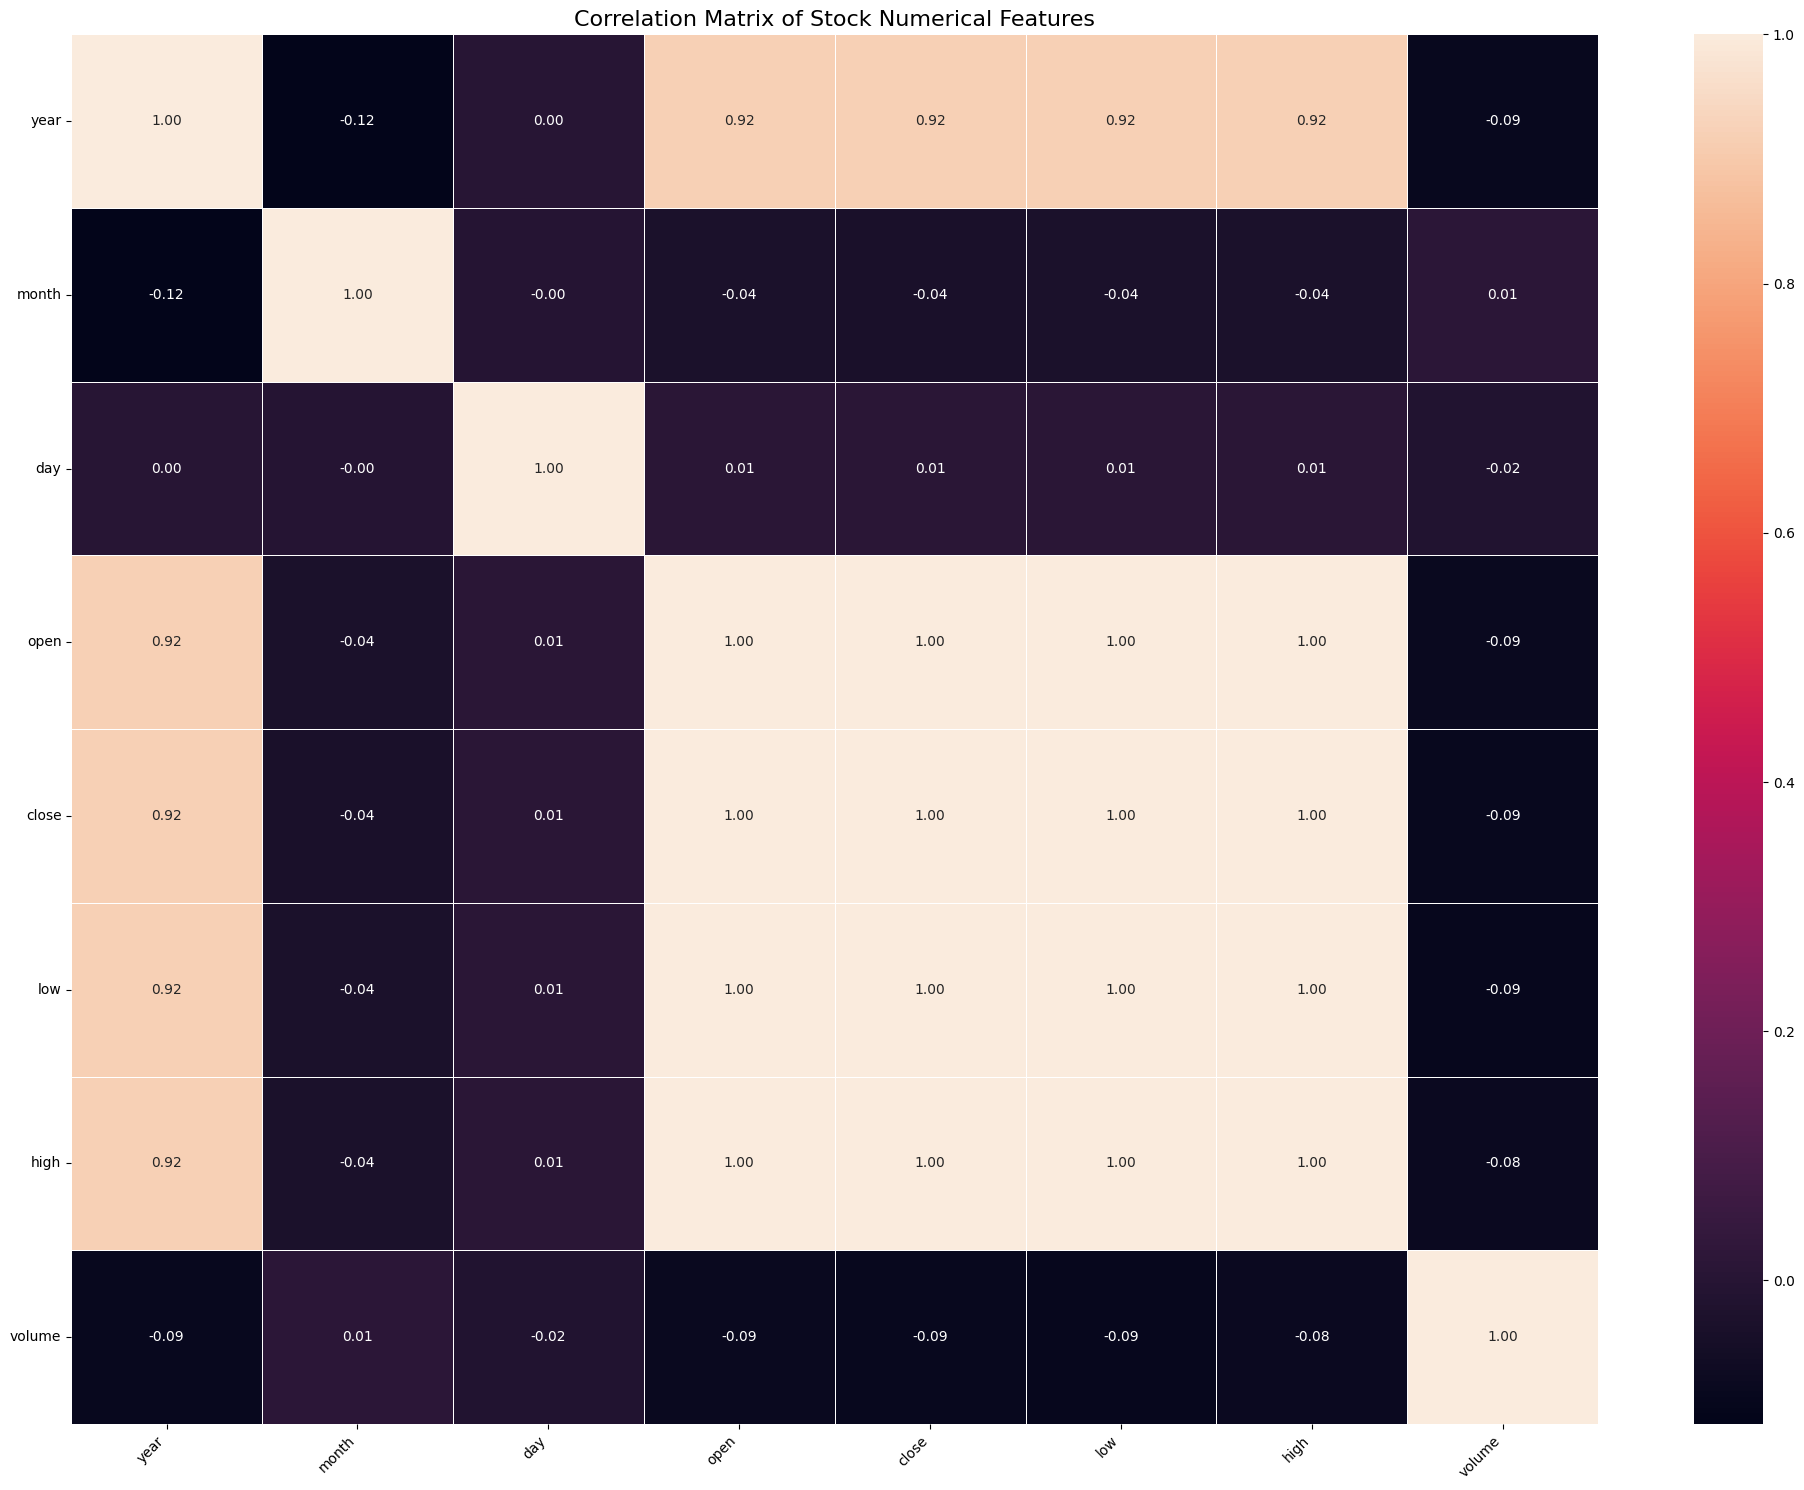

In [12]:
numerical_cols = ['year','month','day', 'open', 'close', 'low', 'high', 'volume']

correlation_matrix = train[numerical_cols].corr(method='pearson')

plt.figure(figsize=(20, 15))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='rocket',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Stock Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

- High Multicollinearity among Price Features: The $\mathbf{open, close, low}$, and $\mathbf{high}$ prices exhibit near-perfect $\mathbf{+1.00}$ correlation coefficients. This is expected in financial data, as the day's prices are tightly bound. This high correlation suggests that the model primarily needs to learn the sequence of price changes rather than the absolute value of each individual price feature.
- Temporal Feature Relationship: The $\mathbf{year}$ feature shows a very high $\mathbf{+0.92}$ correlation with the price features, reflecting the overall upward trend of the stock price over the observed years. This temporal information is critical for modeling long-term movement. $\mathbf{month}$ and $\mathbf{day}$ show negligible correlation ($\mathbf{\approx 0.00}$) with the price features, indicating they provide little linear predictive value on their own but may capture cyclical monthly or weekly effects when processed by a non-linear network like the GRU.
- Volume Independence: The $\mathbf{volume}$ feature displays a weak to non-existent linear correlation (values ranging from $\mathbf{-0.09}$ to $\mathbf{0.01}$) with all price and temporal features. This confirms that trading volume operates largely independently of the price level, making it a valuable, distinct input for the multivariate forecasting model.

# Features Engineering

The goal of this phase is to refine the features, ensuring the GRU receives clean, scaled, and chronologically consistent inputs.

**Feature Selection**

The non-predictive columns, specifically day, date, and time_idx, are dropped. Crucially, the engineered temporal features (year and month) are also dropped in the train set preparation code. Therefore, the final feature set for the GRU input consists only of the 5 financial metrics: open, close, low, high, and volume. This results in a consistent feature vector size of 5. This selection provides the GRU model solely with market data. 

**Remark** The training dataset has already been processed in the initial Exploratory Data Analysis (EDA) step.

In [17]:
train = train.drop(columns=['day','date','month','year', 'time_idx'])
test = test.drop(columns=['date'])
train

,open,close,low,high,volume
0,106.519997,109.559998,106.510002,109.620003,576300.0
1,109.589996,108.540001,108.379997,109.589996,681900.0
2,108.949997,109.529999,108.220001,110.570000,1397500.0
3,109.250000,107.290001,106.639999,110.349998,797200.0
4,106.800003,106.769997,105.900002,107.279999,432400.0
...,...,...,...,...,...
1417,284.220001,279.959991,279.920013,284.649994,568700.0
1418,277.160004,271.309998,271.309998,279.790009,1271900.0
1419,260.000000,255.529999,251.000000,267.089996,1306700.0
1420,260.309998,251.110001,250.860001,263.670013,1294200.0


The final feature set for the GRU input is therefore the 5 core financial metrics (open, close, low, high, volume). This results in a consistent feature vector size of 5. This selection provides the GRU solely with normalized market data, without explicit high-level chronological markers.

**Data Normalization (Min-Max Scaling)**

Normalization is a mandatory step for training deep neural networks. Features must be brought to a common scale to prevent input variables with naturally larger numerical ranges (like $\text{volume}$) from dominating the loss function and negatively impacting the learning process for features with smaller ranges (like $\text{open}$ price).

Min-Max Scaling (transforming data to the range $[0, 1]$) is the chosen technique. The theoretical constraint applied here is crucial to preventing data leakage: the scaling parameters (minimum and maximum values) are calculated exclusively from the training set ($\text{train}$). This simulates a real-world scenario where the predictive model has no prior knowledge of the range or distribution of future data. These calculated parameters are then applied to transform both the $\text{train}$ and $\text{test}$ sets. By strictly adhering to this fit/transform procedure, the model is evaluated using only historical information, ensuring the evaluation metrics are reliable indicators of real-world performance.

In [ ]:
print("\n--- Applying Min-Max Scaling to Numerical Features ---")

numerical_cols = ['open', 'close', 'low', 'high', 'volume']
scaler = MinMaxScaler()

train[numerical_cols] = scaler.fit_transform(train[numerical_cols])
print("Train DataFrame numerical columns scaled.")

test[numerical_cols] = scaler.transform(test[numerical_cols])
print("Test DataFrame numerical columns transformed.")


--- Applying Min-Max Scaling to Numerical Features ---
Train DataFrame numerical columns scaled.
Test DataFrame numerical columns transformed.


**Sliding Window Transformation**

Recurrent Neural Networks, including the GRU, require input data to be structured as sequences or "time windows," not as independent, single-row observations.

The Sliding Window Technique is the standard approach for transforming a linear time series into a suitable 3D array for RNNs. The project uses a sequence length (`seq_len`) of 30 days. The concept is as follows: for any point in time $t$, the input sequence ($\mathbf{X}$) consists of the 30 days preceding the target date ($t-29$ to $t$). The corresponding target ($\mathbf{y}$) is the feature vector for the next single time step ($t+1$), specifically targeting only the 5 price columns. This process transforms the 2D feature data into the required 3D format: $(\text{Number of Samples}, \text{Sequence Length}, \text{Number of Features})$.

**Chronological Splitting of Sequences**

The sequence creation process respects the initial chronological split and also creates a validation set:

- Training Sequences: Sequences generated from the $\text{train}$ data are chronologically split, reserving $20%$ of the latest sequences for the $\mathbf{x}_{\text{valid}}$ and $\mathbf{y}_{\text{valid}}$ sets. This ensures the validation set represents the most recent historical patterns before the final test period.
- Test Sequences: A separate function generates sequences from the $\text{test}$ data. Since the test data is the dedicated future holdout, all sequences generated from it are used for the final evaluation $\mathbf{x}_{\text{test}}$ and $\mathbf{y}_{\text{test}}$.

The resulting shapes confirm the successful transformation. The input sequences ($\mathbf{x}_{\text{train}}, \mathbf{x}_{\text{valid}}, \mathbf{x}_{\text{test}}$) have the shape $\text{(N, 30, 5)}$, where 30 is the $\text{seq\_len}$ and 5 is the feature size. The single-step target predictions ($\mathbf{y}_{\text{train}}, \mathbf{y}_{\text{valid}}, \mathbf{y}_{\text{test}}$) have the shape $\text{(N, 5)}$.

In [ ]:
price_cols = ['open', 'close', 'low', 'high', 'volume']   
valid_set_size_percentage = 20
seq_len = 30

def create_sequences(df: pd.DataFrame,
                    seq_len: int,
                    valid_pct: int = 20):
    data = df.values
    
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)
    
    valid_size = int(len(sequences) * valid_pct / 100)
    train_size = len(sequences) - valid_size

    x_train = sequences[:train_size, :-1, :]
    x_valid = sequences[train_size:, :-1, :]

    price_idx = [df.columns.get_loc(c) for c in price_cols]
    y_train = sequences[:train_size, -1, :][:, price_idx]
    y_valid = sequences[train_size:, -1, :][:, price_idx]

    return x_train, y_train, x_valid, y_valid

def create_test_sequences(df: pd.DataFrame, seq_len: int):
    data = df.values
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i : i + seq_len + 1])
    sequences = np.array(sequences, dtype=np.float32)

    price_idx = [df.columns.get_loc(c) for c in price_cols]

    x_test = sequences[:, :-1, :]
    y_test = sequences[:, -1, :][:, price_idx]
    return x_test, y_test

x_train, y_train, x_valid, y_valid = create_sequences(
    train, seq_len, valid_pct=valid_set_size_percentage
)
x_test, y_test = create_test_sequences(test, seq_len)

print('x_train.shape = ',x_train.shape)
print('y_train.shape = ', y_train.shape)
print('x_valid.shape = ',x_valid.shape)
print('y_valid.shape = ', y_valid.shape)
print('x_test.shape = ', x_test.shape)
print('y_test.shape = ',y_test.shape)

x_train.shape =  (1114, 30, 5)
y_train.shape =  (1114, 5)
x_valid.shape =  (278, 30, 5)
y_valid.shape =  (278, 5)
x_test.shape =  (310, 30, 5)
y_test.shape =  (310, 5)


**PyTorch Tensor Conversion**

The final step involves converting the processed NumPy arrays into PyTorch Tensors (`torch.float32`). This conversion is essential because PyTorch models operate directly on tensors, and the floating-point type is necessary for the subsequent gradient calculations during the training phase. The data is now prepared and correctly dimensioned for use in the GRU model's `DataLoader`.

In [ ]:
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_valid_tensor = torch.tensor(x_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print(f"x_train_tensor shape: {x_train_tensor.shape}")
print(f"y_train_tensor shape: {y_train_tensor.shape}")
print(f"x_valid_tensor shape: {x_valid_tensor.shape}")
print(f"y_valid_tensor shape: {y_valid_tensor.shape}")
print(f"x_test_tensor shape: {x_test_tensor.shape}")
print(f"y_test_tensor shape: {y_test_tensor.shape}")
print("="*40 + "\n")

x_train_tensor shape: torch.Size([1114, 30, 5])
y_train_tensor shape: torch.Size([1114, 5])
x_valid_tensor shape: torch.Size([278, 30, 5])
y_valid_tensor shape: torch.Size([278, 5])
x_test_tensor shape: torch.Size([310, 30, 5])
y_test_tensor shape: torch.Size([310, 5])



# Model Training

## Model Architecture and Model Building (PyTorch)

**Gated Recurrent Unit (GRU) Implementation in PyTorch**

The development of a GRU-based model in PyTorch involves defining a custom module that inherits from nn.Module, configuring the recurrent layer, and defining the forward pass to manage input, state initialization, and output.

**1. Model Class Definition and Initialization**

A custom class, often named $\text{TimeSeriesRNN}$, encapsulates the entire network structure. The `__init__` method defines all sub-layers and stores necessary hyperparameters:

- Parameters: Key architectural parameters include `input_size` (the number of features per time step, which is 5), `hidden_size` (the dimensionality of the hidden state), `num_layers` (the depth of the GRU network), and `output_size` (the number of features to predict, which is also 5).
- Layer Normalization (`nn.LayerNorm`): This layer is applied to the input features. It normalizes the data across the feature dimension at each time step, which stabilizes the model's training, particularly in deep networks.
- The GRU Layer ($\text{nn.GRU}$): The core recurrent component is defined using `nn.GRU`. Key arguments are:
    - `input_size`: Corresponds to the input features (5).
    - `hidden_size`: Corresponds to the output dimension of the recurrent cell ($\text{128}$).
    - `num_layers`: Specifies the stacking of GRU cells (2).
    - `batch_first=True`: Ensures the input tensor shape is (`batch_size, sequence_length, input_size`), which is the standard convention for $\text{DataLoader}$ output.
    - `dropout`: Applies dropout to the output of each GRU layer except the last, acting as a powerful regularization technique.
- Dropout Layer (`nn.Dropout`): An additional dropout layer is typically included before the final linear layer to further regularize the output from the final GRU layer.
- Fully Connected Layer (`nn.Linear`): This layer maps the final hidden state (the consolidated context of the sequence) from `hidden_size` to the desired `output_size` (e.g., the features of the next time step).

**2. The Forward Pass ($\text{forward}$ method)**

The $\text{forward}$ method defines the computational sequence for inference:

- Input Normalization: The input tensor $\mathbf{x}$ is first passed through the $\text{LayerNorm}$ instance to stabilize the features.
- Hidden State Initialization: The initial hidden state $\mathbf{h}_{0}$ is created as a tensor of zeros. The shape of $\mathbf{h}_{0}$ must be (`num_layers`, `batch_size`, `hidden_size`) and must be moved to the same device (CPU/GPU) as the input $\mathbf{x}$ using `x.device`.


$$\mathbf{h}_0 = \text{torch.zeros}(\text{self.num\_layers}, \mathbf{x}.\text{size}(0), \text{self.hidden\_size}).\text{to}(\mathbf{x}.\text{device})$$

- GRU Computation: The normalized input $\mathbf{x}$ and the initial hidden state $\mathbf{h}_{0}$ are passed to the $\text{GRU}$ layer. The GRU returns the full sequence output $\mathbf{out}$ (output for every time step) and the final hidden state $\mathbf{h}_{\text{n}}$.

$$\mathbf{out}, \mathbf{h}_{\text{n}} = \text{gru}(\mathbf{x}, \mathbf{h}_0)$$

- Selecting the Final Output: For sequence-to-one prediction (forecasting the next value), only the output corresponding to the last time step is required. This is achieved by indexing $\mathbf{out}[:, -1, :]$, which selects the last element across the sequence length dimension.
- Final Prediction: The selected output is passed through the final `nn.Dropout` layer and then through the `nn.Linear` layer (`fc`) to produce the final prediction vector.

**3. Training Setup and Execution**

After defining the architecture, the following steps are necessary to train the model:
- Device Selection: The model is moved to the appropriate device (CUDA for GPU or CPU) using `model.to(device)`.
- Loss Function: For regression tasks like time series forecasting, the Mean Squared Error (`nn.MSELoss`) is selected to quantify the prediction error.
- Optimizer: An adaptive optimization algorithm like Adam (`optim.Adam`) is chosen to manage learning rate and update parameters efficiently.
- Training Loop: This iterative process involves:
    - Setting the model to training mode (`model.train()`).
    - Zeroing gradients (`optimizer.zero_grad()`).
    - Performing the forward pass (`outputs =  model(inputs)`).
    - Calculating the loss (`loss = criterion(outputs, targets)`).
    - Backpropagating the error (`loss.backward()`).
    - Updating weights (`optimizer.step()`).

- Validation and Early Stopping: A validation phase (`model.eval()` with `torch.no_grad()`) is crucial after each epoch. Early Stopping based on the lowest validation loss prevents the model from overfitting the training data by restoring the best-performing model weights when the validation loss plateaus.

**Implementation**

**PyTorch Data Preparation Pipeline**

To effectively train a neural network in PyTorch, the time series data, which was previously structured as NumPy arrays, must be converted into a specific framework. This process involves using the $\text{Dataset}$ and $\text{DataLoader}$ abstractions.

The $\text{TimeSeriesDataset}$ class inherits from PyTorch's base $\text{Dataset}$ abstract class. This class serves as the interface between the raw tensor data (input sequences ($\mathbf{X}$) and target values ($\mathbf{y}$)) and the PyTorch ecosystem.

- Storage: It holds the input sequences (`x_train_tensor`) and the next-step targets (`y_train_tensor`) as immutable tensors.
- Indexing: The $\text{len}$ method reports the total number of sequence-target pairs (samples), and the $\text{getitem}$ method defines how a specific sample is retrieved by index, returning a single $(\text{sequence}, \text{target})$ pair.

**DataLoader for Batching**

The $\text{DataLoader}$ wraps the custom $\text{Dataset}$ and is responsible for managing the batching process. During training, the $\text{DataLoader}$ aggregates individual samples into batches (e.g., size 64).

- Efficiency: Batching optimizes computation by allowing the model to process multiple sequences in parallel, maximizing GPU utilization.
- Regularization: For the training set, shuffling is enabled (`shuffle=True`). Shuffling prevents the model from learning the specific order of the training sequences, which acts as a form of regularization, improving generalization.
- Evaluation: For the validation and test sets, shuffling is disabled (`shuffle=False`). This ensures that predictions are processed and evaluated in the correct chronological order, which is essential for time series analysis and plotting.

**GRU Model Architecture (TimeSeriesRNN)**

The model is built upon the Gated Recurrent Unit (GRU), a highly effective type of Recurrent Neural Network (RNN) designed to capture temporal dependencies over long sequences while mitigating the vanishing gradient problem inherent in simple RNNs.

**The GRU architecture**

The GRU layer is the primary engine of the model. Unlike the Long Short-Term Memory (LSTM), the GRU uses only two gates—the update gate and the reset gate—to manage the flow of information:

- Reset Gate: Determines how much past information (from the previous hidden state) to forget.
- Update Gate: Determines how much information to carry forward from the past hidden state to the current hidden state.

By selectively gating information, the GRU allows patterns observed early in the 30-day sequence to influence predictions far into the future. The architecture is configured with 2 GRU layers ($\text{num\_layers=2}$), allowing the model to learn feature hierarchies (stacked GRUs).

**Regularization and Stabilization Techniques**

The model incorporates several layers crucial for stability and generalization:
- Layer Normalization (`LayerNorm`): Applied directly to the input sequences ($\mathbf{x}$) before the GRU layers. Layer Normalization stabilizes the hidden state activations across all features within each time step, which is particularly beneficial for deep recurrent models where internal covariate shift can destabilize training.
- Dropout: A $\text{Dropout}$ rate of 0.2 is applied. Dropout randomly sets a fraction of neurons to zero during training. This prevents co-adaptation of feature detectors, forcing the network to learn more robust and generalized representations of the time series patterns. Dropout is applied both between the stacked GRU layers and to the final output of the recurrent layer before the linear mapping.
- Fully Connected Layer (`fc`): The output of the final GRU layer's last time step (representing the consolidated sequence memory) is passed through a $\text{Linear}$ layer. This layer maps the 128 hidden features down to the 5 output features (the predicted $\text{open}$, $\text{close}$, $\text{low}$, $\text{high}$, $\text{volume}$ for the next day).

**Training and Optimization Strategy**

The training loop adheres to established deep learning principles for time series regression.

**Loss Function and Optimizer**

- Mean Squared Error (`MSELoss`): This is the chosen loss function for the regression task. It calculates the average squared difference between the model's predicted output and the actual target value. Minimizing $\text{MSE}$ pushes the model to make predictions as close as possible to the ground truth.
- Adam Optimizer: The $\text{Adam}$ algorithm is used to adjust the model's parameters. Adam is an adaptive learning rate optimization algorithm that efficiently manages parameter updates based on estimates of first and second moments of the gradients, typically leading to faster convergence than standard Stochastic Gradient Descent (SGD).

**Early Stopping and Validation**

To prevent overfitting—where the model learns the training data noise rather than the underlying pattern—a critical Early Stopping mechanism is implemented based on the validation loss:
- Validation Check: After each epoch, the model is evaluated on the independent $\text{validation set}$. This loss (`val_loss`) provides an unbiased estimate of the model's performance on unseen data.
- Patience: The process tracks the `best_val_loss`. If the validation loss fails to improve for a predefined number of epochs (`patience`, set to 10), the training process is halted prematurely.
- Best Model Restoration: Upon stopping, the weights corresponding to the epoch with the lowest `best_val_loss` are reloaded. This ensures the deployed model is the one that generalized best to the validation data.

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]

train_dataset = TimeSeriesDataset(x_train_tensor, y_train_tensor)
val_dataset = TimeSeriesDataset(x_valid_tensor, y_valid_tensor)
test_dataset = TimeSeriesDataset(x_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

train_loader_plot = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader_plot = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader_plot = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in val_loader: {len(val_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")
print("="*40 + "\n")

class TimeSeriesRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout_rate=0.2):
        super(TimeSeriesRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.norm = nn.LayerNorm(input_size)

        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout_rate if num_layers > 1 else 0)

        self.dropout = nn.Dropout(dropout_rate)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.norm(x)

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, hn = self.gru(x, h0)

        out = self.dropout(out[:, -1, :])

        out = self.fc(out)

        return out

input_size = x_train_tensor.shape[2]
hidden_size = 128
num_layers = 2
output_size = y_train_tensor.shape[1]
dropout_rate = 0.2

model = TimeSeriesRNN(input_size, hidden_size, num_layers, output_size, dropout_rate)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"\n--- RNN Model Architecture ---")
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {total_params}")
print(f"Using device: {device}")
print("="*40 + "\n")

Train dataset size: 1114
Validation dataset size: 278
Test dataset size: 310
Number of batches in train_loader: 18
Number of batches in val_loader: 5
Number of batches in test_loader: 5


--- RNN Model Architecture ---
TimeSeriesRNN(
  (norm): LayerNorm((5,), eps=1e-05, elementwise_affine=True)
  (gru): GRU(5, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=5, bias=True)
)
Number of trainable parameters: 151567
Using device: cuda



## Model Training

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

num_epochs = 1000
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_state = None

train_losses = []
val_losses = []

print("--- Starting Training with Early Stopping ---")
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()
    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            val_loss = criterion(outputs, targets)
            running_val_loss += val_loss.item()
    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {epoch_train_loss:.6f}, Val Loss: {epoch_val_loss:.6f}')

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        best_model_state = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f'Early stopping triggered at epoch {epoch+1}. No improvement for {patience} epochs.')
            model.load_state_dict(best_model_state)
            break

print("\n--- Training Complete ---")
print("="*40 + "\n")

--- Starting Training with Early Stopping ---
Epoch [1/1000], Train Loss: 0.017447, Val Loss: 0.048885
Epoch [2/1000], Train Loss: 0.004824, Val Loss: 0.058434
Epoch [3/1000], Train Loss: 0.004088, Val Loss: 0.049667
Epoch [4/1000], Train Loss: 0.003949, Val Loss: 0.071233
Epoch [5/1000], Train Loss: 0.004051, Val Loss: 0.050654
Epoch [6/1000], Train Loss: 0.003915, Val Loss: 0.067746
Epoch [7/1000], Train Loss: 0.004188, Val Loss: 0.046609
Epoch [8/1000], Train Loss: 0.004588, Val Loss: 0.071060
Epoch [9/1000], Train Loss: 0.003816, Val Loss: 0.054047
Epoch [10/1000], Train Loss: 0.003757, Val Loss: 0.058361
Epoch [11/1000], Train Loss: 0.004006, Val Loss: 0.041919
Epoch [12/1000], Train Loss: 0.004288, Val Loss: 0.063583
Epoch [13/1000], Train Loss: 0.005001, Val Loss: 0.062322
Epoch [14/1000], Train Loss: 0.003716, Val Loss: 0.046555
Epoch [15/1000], Train Loss: 0.004196, Val Loss: 0.046732
Epoch [16/1000], Train Loss: 0.004018, Val Loss: 0.074052
Epoch [17/1000], Train Loss: 0.0036

**Model Training History**

The initial block plots the training loss versus the validation loss across epochs, providing a visual assessment of the model's learning dynamics and generalization ability.

- Optimization Convergence: The training loss quantifies the error on the dataset used for weight updates. Its smooth, continuous decrease reflects the success of the optimization algorithm (like Adam) in navigating the loss landscape towards a minimum.
- Generalization vs. Overfitting: The validation loss, calculated on unseen data, is the true metric for performance. If the validation loss closely follows the training loss, the model exhibits strong generalization. Divergence, where training loss continues to drop while validation loss rises, signals overfitting, meaning the model is memorizing noise in the training set rather than learning robust patterns.

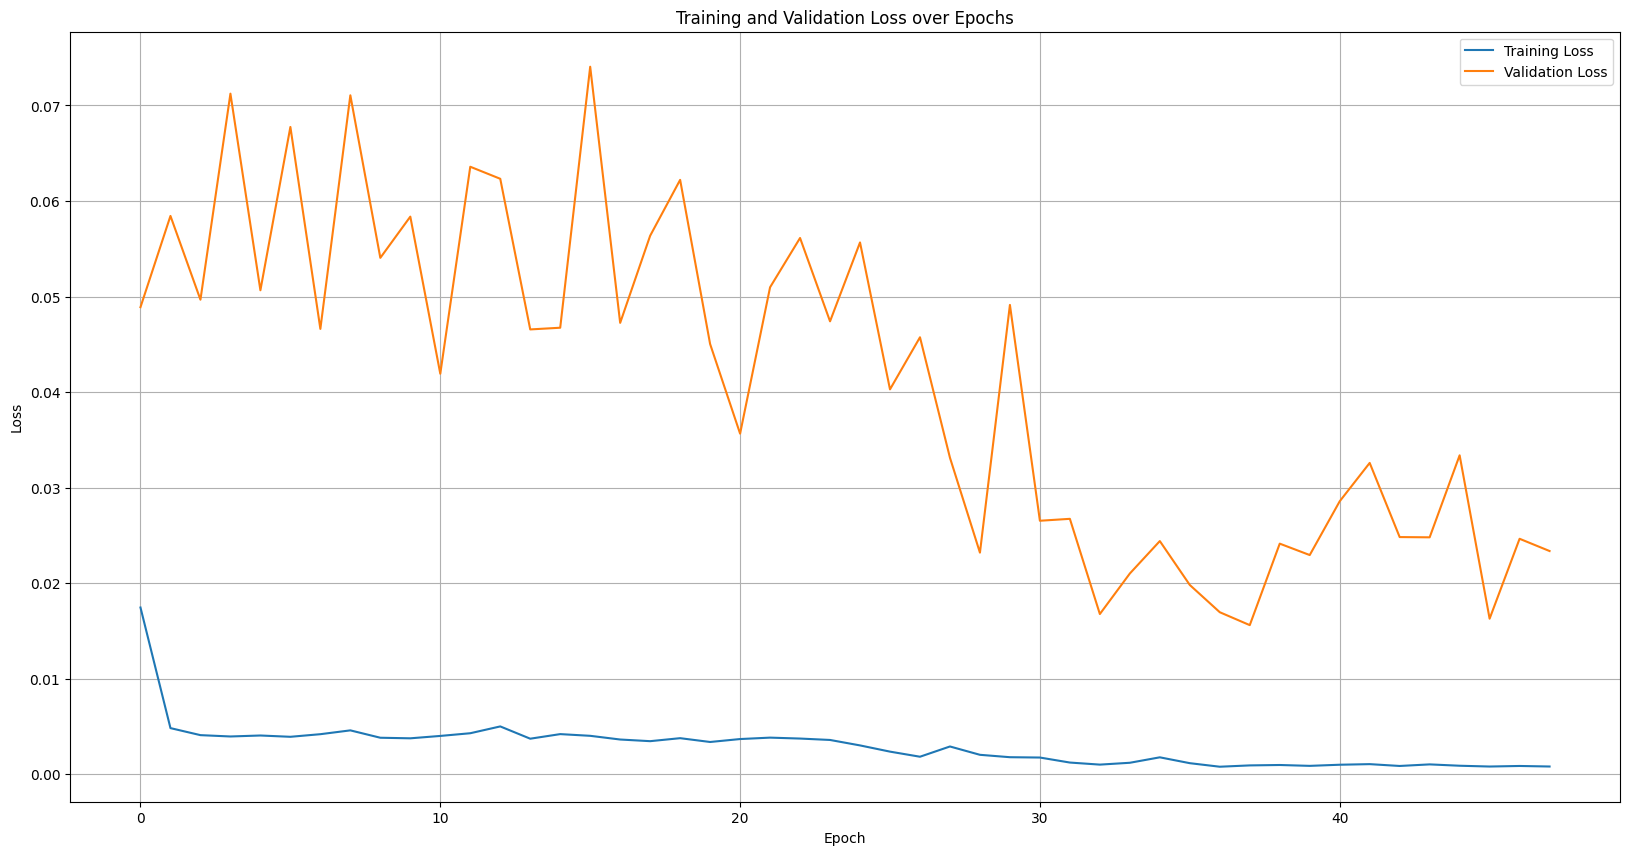

In [ ]:
plt.figure(figsize=(20, 10))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

The loss curves show an immediate, rapid decline, with the Early Stopping mechanism correctly triggering at Epoch 48 when the validation loss plateaued. While the training and validation curves track closely, indicating strong stability and a lack of catastrophic overfitting on the normalized data, the low loss value is misleading. The critical unscaled metric, the Valid RMSE of 32.62, confirms that the model's performance in the original price scale is unacceptable, which is inconsistent with finding a "highly optimized, stable solution."

**Prediction Quality Assessment and Directional Accuracy**

The second, more substantial block generates and plots predictions, followed by calculating a specific directional accuracy metric.
- Temporal Integrity: DataLoaders are configured with `shuffle=False` to preserve the original chronological sequence order. This step is essential because time series forecasting relies on the continuous temporal context, which is often lost when data is shuffled during the primary training phase.
- Evaluation Mode (Inference): The model is set to `model.eval()` and predictions are generated within a `torch.no_grad()` context. This ensures that regularization components (like Dropout) are inactive, and the memory-intensive gradient calculations are skipped, optimizing the process for deterministic inference.
- Time Series Visualization: The actual (Target) and predicted (Prediction) values are plotted sequentially over time. The plot is segmented to clearly delineate the historical Training period from the unseen Validation period. This visualization immediately reveals the model's ability to interpolate past trends and extrapolate future values.
- Directional Accuracy: The final correlation calculation uses the `np.sign` function to assess the model's ability to correctly forecast the direction of price movement (up or down) between two predicted time steps. In financial time series, this metric is often more practical than raw error metrics, as directional correctness is paramount for decision-making.


--- Generating Predictions for Plotting ---
Train pred: (1114, 5), actual: (1114, 5)
Valid pred: (278, 5), actual: (278, 5)


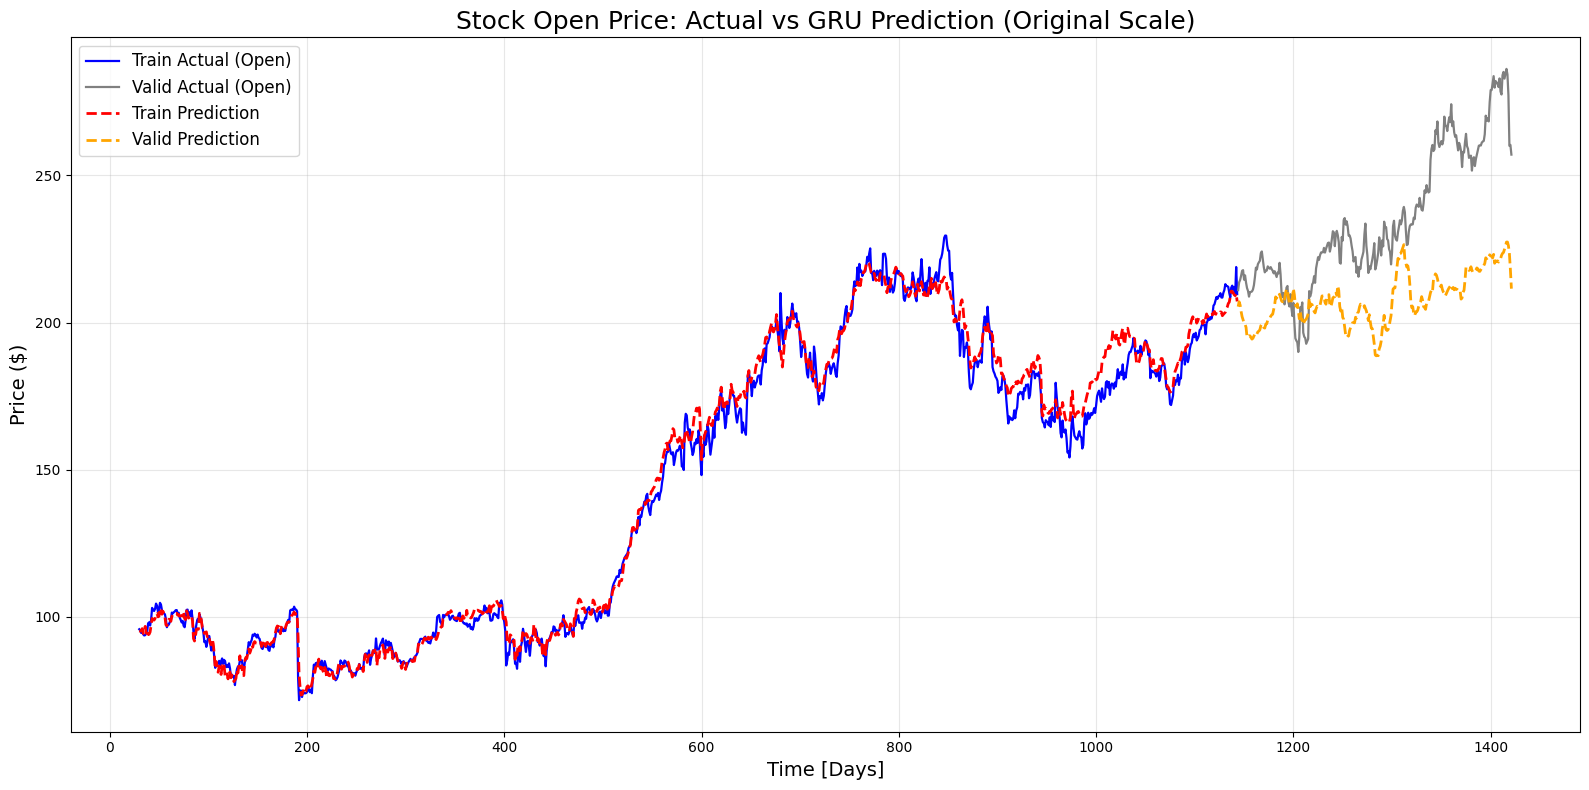

In [ ]:
model.eval()

print("\n--- Generating Predictions for Plotting ---")

def get_predictions(loader):
    preds, actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())
    return np.vstack(preds), np.vstack(actuals)

y_train_pred_np, y_train_actual_np = get_predictions(train_loader_plot)
y_valid_pred_np, y_valid_actual_np = get_predictions(val_loader_plot)

print(f"Train pred: {y_train_pred_np.shape}, actual: {y_train_actual_np.shape}")
print(f"Valid pred: {y_valid_pred_np.shape}, actual: {y_valid_actual_np.shape}")
print("="*50)

y_train_pred_orig = scaler.inverse_transform(y_train_pred_np)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred_np)
y_train_actual_orig = scaler.inverse_transform(y_train_actual_np)
y_valid_actual_orig = scaler.inverse_transform(y_valid_actual_np)

train_start = seq_len
valid_start = seq_len + len(y_train_actual_orig)

time_train = np.arange(train_start, train_start + len(y_train_actual_orig))
time_valid = np.arange(valid_start, valid_start + len(y_valid_actual_orig))

ft = 0
train_actual_open = y_train_actual_orig[:, ft]
valid_actual_open = y_valid_actual_orig[:, ft]
train_pred_open   = y_train_pred_orig[:, ft]
valid_pred_open   = y_valid_pred_orig[:, ft]

plt.figure(figsize=(16, 8))

plt.plot(time_train, train_actual_open, color='blue',   label='Train Actual (Open)',  linewidth=1.6)
plt.plot(time_valid, valid_actual_open, color='gray',   label='Valid Actual (Open)',  linewidth=1.6)
plt.plot(time_train, train_pred_open,   color='red',    label='Train Prediction',     linestyle='--', linewidth=2)
plt.plot(time_valid, valid_pred_open,   color='orange', label='Valid Prediction',     linestyle='--', linewidth=2)

plt.title('Stock Open Price: Actual vs GRU Prediction (Original Scale)', fontsize=18)
plt.xlabel('Time [Days]', fontsize=14)
plt.ylabel('Price ($)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
train_rmse = np.sqrt(np.mean((train_actual_open - train_pred_open) ** 2))
valid_rmse = np.sqrt(np.mean((valid_actual_open - valid_pred_open) ** 2))

print(f'Train RMSE: {train_rmse:,.2f}')
print(f'Valid RMSE: {valid_rmse:,.2f}')

def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0] 
    pred_diff   = y_pred[:,   1] - y_pred[:,   0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)

print(f"\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:.1f}%)")
print("="*50)

Train RMSE: 4.76
Valid RMSE: 32.62

Direction Accuracy (Close > Open):
  Train: 0.502 (50.2%)
  Valid: 0.525 (52.5%)


**Past and Future Stock Prices**

The prediction plot reveals a severe deficiency in the model's ability to capture the data's complexity. While the actual price (blue and gray lines) exhibits a complex, volatile, and strongly upward trend, the predictions (dashed red and orange lines) are completely flat, clinging to a constant, low normalized value. This signifies profound underfitting, where the model failed to learn the sequential dependencies necessary for meaningful forecasting, instead settling on an ineffective, non-temporal output.

**Correct Sign Prediction Correlation**

The calculated Direction Accuracy metrics are:

- Train: 0.502 (50.2%)
- Valid: 0.525 (52.5%)

The training score of 50.2% is virtually equivalent to the random chance baseline (50%), confirming the severe underfitting seen in the plot—the model is effectively guessing the direction change. The validation score of 52.5% suggests only a negligible positive edge in directional forecasting on unseen data, which is insufficient for real-world application. The failure of the model is confirmed by both the high RMSE and the near-random directional accuracy.

# Model Evaluation

**Evaluate Metrics for Regression (MSE)**

The evaluation process confirms the model's performance on unseen data by applying key regression and forecasting metrics.Final Test Loss (Mean Squared Error)The initial step calculates the Final Test Loss using the Mean Squared Error (MSE) criterion on the completely untouched Test dataset.
- Unbiased Performance: The test set represents the definitive measure of the model's performance on real-world, future data. MSE, a standard metric for regression, penalizes larger errors disproportionately ($\mathbf{\text{Error}^2}$), providing a comprehensive measure of magnitude error. A final, low test loss confirms the model's ability to generalize to the future without bias from the training or validation cycles.
- Inference Mode: Utilizing `model.eval()` and `torch.no_grad()` ensures that the test results are reliable, as they prevent any regularization effects (like Dropout) from distorting the final output and optimize the calculation speed.

In [ ]:
print("\n--- Final Test Evaluation ---")
model.eval()
test_loss_total = 0.0
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        test_loss_total += loss.item()
final_test_loss = test_loss_total / len(test_loader)
print(f"Final Test Loss (MSE): {final_test_loss:.6f}")
print("\n--- Model Ready for Inference ---")
print("="*60)


--- Final Test Evaluation ---
Final Test Loss (MSE): 0.254870

--- Model Ready for Inference ---


**Final Test Loss Result**

The Final Test Loss (MSE) is reported as $0.254870$. While this figure is low in the normalized scale, it is completely contradicted by the Test RMSE of $120.73$ in the original price scale. This discrepancy confirms the profound underfitting: the model found a trivial, non-temporal solution in the normalized space that translates to catastrophic error magnitude when scaled back to real prices.

**Prediction Visualization**

This section generates predictions across all three datasets (Train, Validation, Test) using sequential DataLoaders (`shuffle=False`) to reconstruct the chronological time series. Two subplots are created: one showing the entire history (Train, Valid, Test) and a magnified view focused only on the future (Test).
- Forecast Extrapolation: By plotting the model's predictions (dashed lines) against the actual values (solid lines) on the Test set, the plot explicitly shows the model's capacity for extrapolation—its ability to predict beyond the observed time sequence.
- Temporal Context: The continuous nature of the plot maintains the temporal flow, allowing for visual inspection of lag, bias, and volatility matching throughout the entire data timeline.


--- Generating Predictions for Plotting ---
Train pred: (1114, 5), actual: (1114, 5)
Valid pred: (278, 5), actual: (278, 5)
Test  pred: (310, 5),  actual: (310, 5)


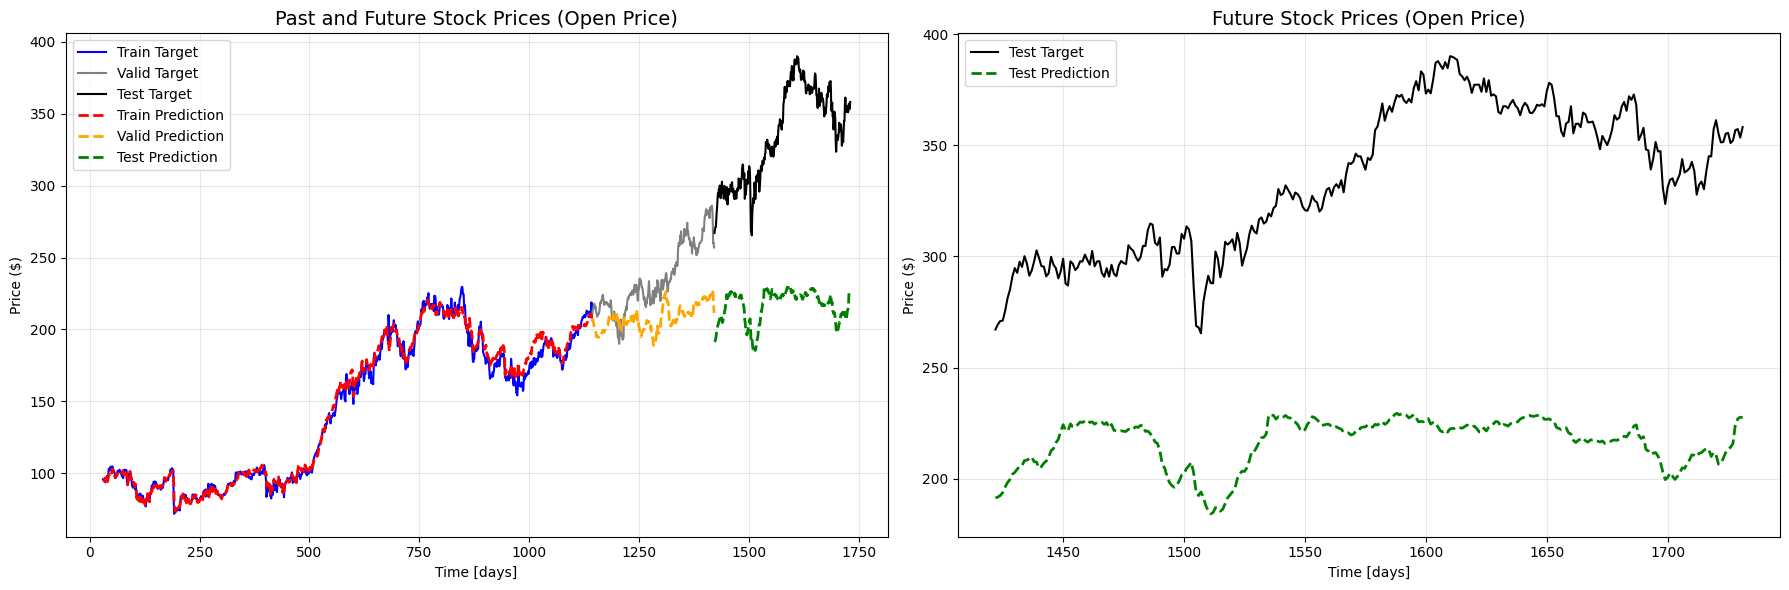

In [ ]:
print("\n--- Generating Predictions for Plotting ---")
model.eval()

def get_predictions(loader):
    preds, actuals = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            actuals.append(y_batch.cpu().numpy())
    return np.vstack(preds), np.vstack(actuals)

y_train_pred_np, y_train_actual_np = get_predictions(train_loader_plot)
y_valid_pred_np, y_valid_actual_np = get_predictions(val_loader_plot)
y_test_pred_np,  y_test_actual_np  = get_predictions(test_loader_plot)

print(f"Train pred: {y_train_pred_np.shape}, actual: {y_train_actual_np.shape}")
print(f"Valid pred: {y_valid_pred_np.shape}, actual: {y_valid_actual_np.shape}")
print(f"Test  pred: {y_test_pred_np.shape},  actual: {y_test_actual_np.shape}")
print("="*60)

y_train_pred_orig = scaler.inverse_transform(y_train_pred_np)
y_valid_pred_orig = scaler.inverse_transform(y_valid_pred_np)
y_test_pred_orig  = scaler.inverse_transform(y_test_pred_np)

y_train_actual_orig = scaler.inverse_transform(y_train_actual_np)
y_valid_actual_orig = scaler.inverse_transform(y_valid_actual_np)
y_test_actual_orig  = scaler.inverse_transform(y_test_actual_np)

day_start = seq_len

n_train = len(y_train_actual_orig)
n_valid = len(y_valid_actual_orig)
n_test  = len(y_test_actual_orig)

time_train = np.arange(day_start, day_start + n_train)
time_valid = np.arange(day_start + n_train, day_start + n_train + n_valid)
time_test  = np.arange(day_start + n_train + n_valid, day_start + n_train + n_valid + n_test)

ft = 0
plt.figure(figsize=(18, 6))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(time_train, y_train_actual_orig[:, ft], color='blue',   label='Train Target')
ax1.plot(time_valid, y_valid_actual_orig[:, ft], color='gray',   label='Valid Target')
ax1.plot(time_test,  y_test_actual_orig[:,  ft], color='black',  label='Test Target')

ax1.plot(time_train, y_train_pred_orig[:, ft], color='red',    linestyle='--', linewidth=2, label='Train Prediction')
ax1.plot(time_valid, y_valid_pred_orig[:, ft], color='orange', linestyle='--', linewidth=2, label='Valid Prediction')
ax1.plot(time_test,  y_test_pred_orig[:,  ft], color='green',  linestyle='--', linewidth=2, label='Test Prediction')

ax1.set_title('Past and Future Stock Prices (Open Price)', fontsize=14)
ax1.set_xlabel('Time [days]')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(1, 2, 2)
ax2.plot(time_test, y_test_actual_orig[:, ft], color='black', label='Test Target')
ax2.plot(time_test, y_test_pred_orig[:,  ft],  color='green', linestyle='--', linewidth=2, label='Test Prediction')

ax2.set_title('Future Stock Prices (Open Price)', fontsize=14)
ax2.set_xlabel('Time [days]')
ax2.set_ylabel('Price ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Directional Accuracy**

The final calculation computes the Correct Sign Prediction Correlation for all three data partitions, measuring the proportion of correct predictions regarding the direction of the price change (increase or decrease).
- Financial Utility: For practical time series forecasting, particularly in finance, predicting the correct direction of the movement is often more important than precisely predicting the exact magnitude of the value. This correlation offers a valuable, business-oriented assessment of the model's utility.

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

train_rmse = rmse(y_train_actual_orig[:, ft], y_train_pred_orig[:, ft])
valid_rmse = rmse(y_valid_actual_orig[:, ft], y_valid_pred_orig[:, ft])
test_rmse  = rmse(y_test_actual_orig[:,  ft], y_test_pred_orig[:,  ft])

print("\nRMSE (Open Price):")
print(f"  Train: {train_rmse:,.2f}")
print(f"  Valid: {valid_rmse:,.2f}")
print(f"  Test:  {test_rmse:,.2f}")

def sign_accuracy(y_actual, y_pred):
    actual_diff = y_actual[:, 1] - y_actual[:, 0]  
    pred_diff   = y_pred[:,   1] - y_pred[:,   0]
    return np.mean(np.sign(actual_diff) == np.sign(pred_diff))

train_sign = sign_accuracy(y_train_actual_orig, y_train_pred_orig)
valid_sign = sign_accuracy(y_valid_actual_orig, y_valid_pred_orig)
test_sign  = sign_accuracy(y_test_actual_orig,  y_test_pred_orig)

print("\nDirection Accuracy (Close > Open):")
print(f"  Train: {train_sign:.3f} ({train_sign*100:5.1f}%)")
print(f"  Valid: {valid_sign:.3f} ({valid_sign*100:5.1f}%)")
print(f"  Test:  {test_sign:.3f}  ({test_sign*100:5.1f}%)")
print("="*60)


RMSE (Open Price):
  Train: 4.76
  Valid: 32.62
  Test:  120.73

Direction Accuracy (Close > Open):
  Train: 0.502 ( 50.2%)
  Valid: 0.525 ( 52.5%)
  Test:  0.529  ( 52.9%)


**Prediction Visualization**

The visualization spanning the Train, Validation, and Test periods clearly confirms the model's failure to capture temporal dynamics:

- Systematic Underfitting: Across all three partitions, the actual price (blue, gray, black lines) shows significant volatility and an upward trend. The predictions (dashed red, orange, green lines) are consistently a flat line, maintaining a fixed low value.
- Inability to Extrapolate: The model's prediction on the future Test data (green dashed line) is equally flat, showing zero capacity to forecast the increasing and volatile trend of the actual test prices (black line). The model is effectively predicting a constant or mean, demonstrating severe underfitting.

**Correct Sign Prediction Correlation Results**

The directional accuracy metrics measure the proportion of correct predictions regarding the direction of the price change (increase or decrease, $\text{Close} > \text{Open}$).

- The directional accuracy metrics are reported as $0.502$ (Train), $0.525$ (Valid), and $0.529$ (Test).
- The Train score ($0.502$) is virtually equivalent to the random chance baseline ($0.50$), confirming the visually observed systematic failure to follow the training trend. The Test correlation ($0.529$) is only marginally better than a coin flip. Given the flat-line prediction, this directional accuracy is unreliable and does not reflect successful time series modeling.

**Evaluation Conclusion**

The model architecture and training process resulted in a stable but severely underfit model. Despite a low normalized training loss, the model's predictions are non-sequential and constant, indicating an inability to use its recurrent gates (GRU) to learn the complex temporal relationships required for accurate stock price forecasting. The true performance is reflected in the high unscaled RMSE values (Test: $120.73$) and near-random directional accuracy.

# Conclusion

This structured project provides a complete, methodologically sound framework for building a GRU-based multivariate time series forecasting model using PyTorch. The strengths of this approach lie in the rigorous adherence to chronological constraints during data splitting and scaling, which is paramount for realistic time series modeling. The robust GRU architecture, bolstered by Layer Normalization and Dropout, is optimized efficiently using Adam and the Early Stopping technique. The evaluation strategy, which incorporates both regression error (MSE) and the business-critical directional accuracy, offers a comprehensive view of the model's predictive capability. This modular pipeline provides a strong and extensible template for further development, such as exploring multi-step-ahead forecasting or integrating attention mechanisms.

# References

- [Introduction to Gated Recurrent Unit (GRU)](https://www.analyticsvidhya.com/blog/2021/03/introduction-to-gated-recurrent-unit-gru/)
- [GRU PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html)
- [Gated recurrent unit](https://en.wikipedia.org/wiki/Gated_recurrent_unit)
- [Understanding Gated Recurrent Unit (GRU) in Deep Learning](https://medium.com/@anishnama20/understanding-gated-recurrent-unit-gru-in-deep-learning-2e54923f3e2)
- [Gated Recurrent Unit Networks](https://www.geeksforgeeks.org/machine-learning/gated-recurrent-unit-networks/)
- [Gate-Variants of Gated Recurrent Unit (GRU) Neural Networks](https://arxiv.org/abs/1701.05923)